# About the Dataset:
'train.csv' is the dataset with the following attributes:

id: unique id for a news article

title: the title of a news article

author: author of the news article

text:the text of the article, it could be incomplete

label: A label that marks whether the news article is real or fake. Here 1 means Fake news and 0 means Real news


Source: https://www.kaggle.com/c/fake-news/data?select=train.csv

## Import the important libraries

In [58]:
import numpy as np   # NumPy provides an array object which is faster than traditional Python lists. 
import pandas as pd   # To works with data sets. It has functions for analyzing, cleaning, exploring, and manipulating data.
import re      # re stands for regular expression
from nltk.corpus import stopwords  # nltk means natural language tool kit
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer  # scikit-learn library (sklearn). Tf means Term frequency and idf means inverse documnet frequency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

import nltk

import matplotlib.pyplot as plt   #visualization library in Python for 2D plots of arrays

from sklearn import metrics

## Loading the dataset to a pandas DataFrame


In [59]:
news_dataset = pd.read_csv('train.csv')  # Here the dataset is save as train.csv

In [60]:
# Print the first 6 rows of the dataframe
news_dataset.head(5)

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [ ]:
# Print the last few rows of the dataframe
news_dataset.tail(5)

,id,title,author,text,label
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1
20799,20799,What Keeps the F-35 Alive,David Swanson,"David Swanson is an author, activist, journa...",1


In [62]:
# Shape of the news dataset
## Here this dataset contains 20800 rows and 5 columns

print("Shape of the given news dataset is:",news_dataset.shape)

Shape of the given news dataset is: (20800, 5)


### Counting the number of missing values in the given dataset

In [63]:
## The isnull() method returns a DataFrame object where all the values are replaced with
## a Boolean value True for NULL values, and otherwise False.

print(news_dataset.isnull().sum())

id           0
title      558
author    1957
text        39
label        0
dtype: int64


### The ratio of number of real news and fake news shown in the following bar diagram

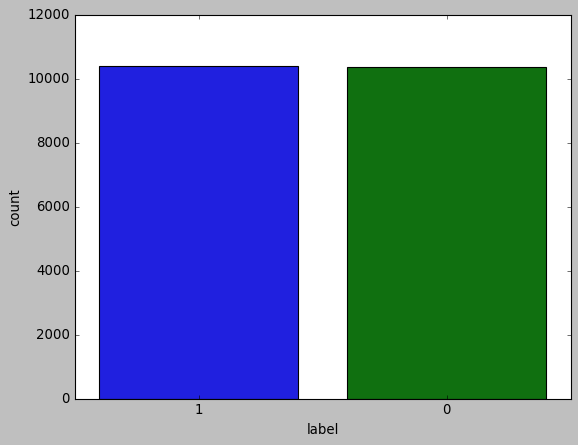

In [64]:
# Bar diagram of label values i.e the number of fake news and real news in the news dataset


import seaborn as sns

sns.countplot(news_dataset, x='label',order=news_dataset['label'].value_counts().index)
plt.show()

### Replacing the null values of given the data set with empty string

In [65]:
## The fillna() method replaces the NULL values with a specified value.
## The fillna() method returns a new DataFrame object unless the inplace parameter is set to True , 
## in that case the fillna() method does the replacing in the original DataFrame instead.

news_dataset = news_dataset.fillna('')

### Merge the author name and the title of the news and store them to a new column names content

In [66]:
news_dataset['content'] = news_dataset['author']+' '+news_dataset['title']

In [67]:
news_dataset['content']

0        Darrell Lucus House Dem Aide: We Didn’t Even S...
1        Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo...
2        Consortiumnews.com Why the Truth Might Get You...
3        Jessica Purkiss 15 Civilians Killed In Single ...
4        Howard Portnoy Iranian woman jailed for fictio...
                               ...                        
20795    Jerome Hudson Rapper T.I.: Trump a ’Poster Chi...
20796    Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma...
20797    Michael J. de la Merced and Rachel Abrams Macy...
20798    Alex Ansary NATO, Russia To Hold Parallel Exer...
20799              David Swanson What Keeps the F-35 Alive
Name: content, Length: 20800, dtype: object

### Separating the data and label

In [68]:
X = news_dataset.drop(columns='label', axis=1)   #axis=1 represents the columns and axis=0 represents the rows
Y = news_dataset['label']

In [69]:
print(X)

          id                                              title  \
0          0  House Dem Aide: We Didn’t Even See Comey’s Let...   
1          1  FLYNN: Hillary Clinton, Big Woman on Campus - ...   
2          2                  Why the Truth Might Get You Fired   
3          3  15 Civilians Killed In Single US Airstrike Hav...   
4          4  Iranian woman jailed for fictional unpublished...   
...      ...                                                ...   
20795  20795  Rapper T.I.: Trump a ’Poster Child For White S...   
20796  20796  N.F.L. Playoffs: Schedule, Matchups and Odds -...   
20797  20797  Macy’s Is Said to Receive Takeover Approach by...   
20798  20798  NATO, Russia To Hold Parallel Exercises In Bal...   
20799  20799                          What Keeps the F-35 Alive   

                                          author  \
0                                  Darrell Lucus   
1                                Daniel J. Flynn   
2                             Consortiu

In [70]:
print(Y)

0        1
1        0
2        1
3        1
4        1
        ..
20795    0
20796    0
20797    0
20798    1
20799    1
Name: label, Length: 20800, dtype: int64


### Stemming:

#### Stemming is the process of reducing a word to its Root word. Example: actor, actress, acting --> act.

In [71]:
port_stem = PorterStemmer()

In [72]:
# Defining a function which stemmed the content

def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [73]:
## THIS CELL TAKES LONGER TIME TO EXECUTE, BECAUSE IT CONTAINS HUGE DATA.

news_dataset['content'] = news_dataset['content'].apply(stemming)

In [74]:
print(news_dataset['content'])

0        darrel lucu hous dem aid even see comey letter...
1        daniel j flynn flynn hillari clinton big woman...
2                   consortiumnew com truth might get fire
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoy iranian woman jail fiction unpu...
                               ...                        
20795    jerom hudson rapper trump poster child white s...
20796    benjamin hoffman n f l playoff schedul matchup...
20797    michael j de la merc rachel abram maci said re...
20798    alex ansari nato russia hold parallel exercis ...
20799                            david swanson keep f aliv
Name: content, Length: 20800, dtype: object


In [75]:
#separating the data and label again

X = news_dataset['content'].values
Y = news_dataset['label'].values

In [76]:
print(X)
print(X.shape)

['darrel lucu hous dem aid even see comey letter jason chaffetz tweet'
 'daniel j flynn flynn hillari clinton big woman campu breitbart'
 'consortiumnew com truth might get fire' ...
 'michael j de la merc rachel abram maci said receiv takeov approach hudson bay new york time'
 'alex ansari nato russia hold parallel exercis balkan'
 'david swanson keep f aliv']
(20800,)


In [77]:
print(Y)
print(Y.shape)

[1 0 1 ... 0 1 1]
(20800,)


### Plot the top 10 most used words in 'content'

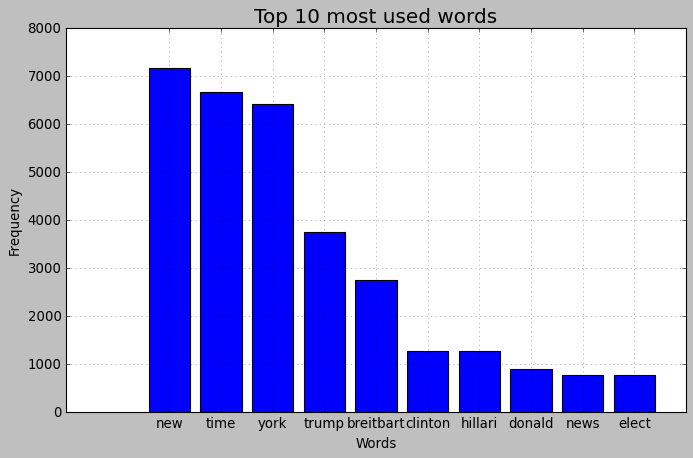

In [78]:
# getting the top 10 most used words in content
import collections

words = []
for text in news_dataset['content']:
    words.extend(text.split())
word_count = collections.Counter(words)
top_words = dict(word_count.most_common(10))
plt.style.use('classic')
plt.figure(figsize = (10, 6))
plt.bar(range(len(top_words)), list(top_words.values()), align='center')
plt.xticks(range(len(top_words)), list(top_words.keys()))
plt.grid(alpha = 0.5)
plt.title('Top 10 most used words', fontsize = 18)
plt.xlabel('Words')
plt.ylabel('Frequency')

plt.show()

### Converting the textual data to numerical data

In [79]:
vectorizer = TfidfVectorizer()
vectorizer.fit(X)

X = vectorizer.transform(X)

In [80]:
print(X)

  (0, 15686)	0.28485063562728646
  (0, 13473)	0.2565896679337957
  (0, 8909)	0.3635963806326075
  (0, 8630)	0.29212514087043684
  (0, 7692)	0.24785219520671603
  (0, 7005)	0.21874169089359144
  (0, 4973)	0.233316966909351
  (0, 3792)	0.2705332480845492
  (0, 3600)	0.3598939188262559
  (0, 2959)	0.2468450128533713
  (0, 2483)	0.3676519686797209
  (0, 267)	0.27010124977708766
  (1, 16799)	0.30071745655510157
  (1, 6816)	0.1904660198296849
  (1, 5503)	0.7143299355715573
  (1, 3568)	0.26373768806048464
  (1, 2813)	0.19094574062359204
  (1, 2223)	0.3827320386859759
  (1, 1894)	0.15521974226349364
  (1, 1497)	0.2939891562094648
  (2, 15611)	0.41544962664721613
  (2, 9620)	0.49351492943649944
  (2, 5968)	0.3474613386728292
  (2, 5389)	0.3866530551182615
  (2, 3103)	0.46097489583229645
  :	:
  (20797, 13122)	0.2482526352197606
  (20797, 12344)	0.27263457663336677
  (20797, 12138)	0.24778257724396507
  (20797, 10306)	0.08038079000566466
  (20797, 9588)	0.174553480255222
  (20797, 9518)	0.295420

### Splitting the dataset for training data & test data

In [81]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 2)

### Train the Logistic Regression Model using Scikit learn

In [82]:
model = LogisticRegression()

In [83]:
model.fit(X_train, Y_train)

LogisticRegression()

### Evaluation
 
#### Accuracy score of training data and test data

In [84]:
# Accuracy score on the training data

X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

In [85]:
# Print the accuracy score of the training data

print(f'Accuracy score of the training data in percentage is: {round(training_data_accuracy*100, 2)}%')

Accuracy score of the training data in percentage is: 98.66%


In [86]:
# Accuracy score on the test data

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

In [87]:
# Print the accuracy score of the test data

print(f'Accuracy score of the test data in percentage is: {round(test_data_accuracy*100, 2)}%')

Accuracy score of the test data in percentage is: 97.91%


### Making a predictive system

In [88]:
X_new = X_test[1]
prediction = model.predict(X_new)
print(prediction)

if(prediction[0] == 0):
    print('The news is Real.')
else:
    print('The news is Fake.')

[0]
The news is Real.


In [89]:
# Check the above output with the original value

print(Y_test[1])

0


## Confusion matrix:

#### It is a table that is used in classification problems to assess where errors in the model were made. The rows represent the actual classes the outcomes should have been. While the columns represent the predictions we have made. Using this table it is easy to see which predictions are wrong. Confusion matrixes can be created by predictions made from a logistic regression.

In [90]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [91]:
# Build the confusion matrix
confusion_matrix=confusion_matrix(Y_test, X_test_prediction)

In [92]:
print(confusion_matrix)

[[2004   73]
 [  14 2069]]


In [93]:
# Here I find the test_data accuracy from the elements of confusion matrix  

testdata_accuracy = (confusion_matrix[0][0]+confusion_matrix[1][1])/confusion_matrix.sum()

# print(testdata_accuracy)
print("\nTest data accuracy:",round(testdata_accuracy*100,2),"%\n")


Test data accuracy: 97.91 %



#### Plot the confusion matrix

In [1]:
# Plotting of confusion matrix
actual = Y_test
predicted = X_test_prediction

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['Real', 'Fake'])

cm_display.plot()
plt.show()

NameError: name 'Y_test' is not defined